# Henkel Düsseldorf Holthausen Pilot
### Data-Driven Energy Business Use Cases & Mathematical Optimization Framework

**Prepared for:** RIZM Application Challenge  
**Target Site:** Henkel Flagship Chemical & Consumer Goods Site, Düsseldorf-Holthausen  
**Primary Metric:** EUR / ton of industrial output (~450,000 tons manufacturing capacity/year baseline)  
**Methodology:** Sector-Coupled MILP via `PyPSA` & `HiGHS` + Real 2025 German Market Data  

---

## Executive Summary & Methodology First Approach

Henkel’s Düsseldorf-Holthausen site is one of Europe’s largest integrated chemical and consumer goods production complexes (~450,000 tons/year combined output across laundry, home care, and adhesives). Energy cost per ton directly dictates site competitiveness and operating margins.

This deliverable demonstrates an MVP that resembles RIZM’s **Agentic Energy OS** in quantifying clear unit cost reductions (€/ton) by evaluating three operational tiers:
1. **Existing Baseline (Rule-Based Heuristic):** Fixed existing utility asset base (Gas CHP & Steam Boilers) operating under traditional static heat-following control and unmitigated spot price exposure.
2. **Operation Hub:** MILP operational dispatch optimization on existing assets, unlocking spot market arbitrage and peak shaving.
3. **Investment Hub (CAPEX/OPEX Co-Optimization):** Joint asset expansion in `PyPSA` using Annualized Equivalent Costs (EAC) to co-optimize capacities for Rooftop PV, Solar/Wind PPA contracts, Battery Storage (BESS), Industrial Heat Pumps (HTHP), E-Boilers, and Thermal Energy Storage (TES).

### Key Methodology Choices:
- **Off-Site Renewable PPAs (Solar & Wind):** Integrates fixed-price, long-term Solar and Wind PPA contracts alongside spot market purchases. This hedges wholesale electricity volatility, reduces site carbon intensity, and powers electrification assets (HTHP/E-Boilers).
- **Dual-Temperature Exergy Cascade:** Explicitly separates High-Temperature Steam (16 bar, ~200 °C) from Mid/Low-Temperature Process Heat (~80 °C). This prevents thermodynamic exergy destruction and models heat recovery cascades (Steam Exchangers & HTHPs at COP 2.8).
- **Empirical 2025 Market & Weather Profiles:** Co-optimized against 8,760 hourly SMARD Day-Ahead electricity prices (filter 4169, DE bidding zone), THE natural gas spot data, and Open-Meteo Düsseldorf solar profiles.
- **Regulatory Peak Shaving:** Integrates German § 19 Abs. 2 StromNEV grid fee reduction incentives by targeting high annual operating hours and flat band-load profiles.


In [1]:
import sys
import importlib
from pathlib import Path
import pandas as pd
from IPython.display import display

# Ensure latest module state is loaded in interactive Jupyter sessions
import src.utils
import src.optimization_model
importlib.reload(src.utils)
importlib.reload(src.optimization_model)

# Import data preparation, Pydantic schemas, and visualization abstractions
from src.external_api import prepare_data_files
from src.optimization_model import (
    HenkelEnergySystem,
    FacilityProjectConfig,
    FixedSizingConfig,
    VariableSizingConfig,
    ComponentBounds,  
)
from src.utils import (
    plot_dispatch_stacks,
    plot_dispatch_stacks_interactive,
    plot_storage_dynamics_interactive,
    plot_price_duration_curves_interactive,
    plot_asset_economics_interactive,
    plot_sec19_grid_fee_protection_interactive,
    create_summary_dataframe,
    create_pypsa_asset_sizing_table,
    explore_network_interactive,
    plot_network_topology_static,
    plot_network_topology_graph,
    plot_network_schematic,
    plot_scenario_cost_per_ton_interactive,
    plot_market_prices_interactive
    
)

print("Core PyPSA Modules, Pydantic Schemas & PyPSA Reporting Suite Loaded Successfully.")


Core PyPSA Modules, Pydantic Schemas & PyPSA Reporting Suite Loaded Successfully.


### Site Energy Demand, Utility Fleet & First-Principles Justification

Henkel’s Düsseldorf-Holthausen flagship complex operates continuously to manufacture laundry detergents, home care products, and industrial adhesives. All site energy parameters and existing utility fleet specs are grounded directly in published technical literature.

#### 1. Site Baseload Demand & Literature References
| Parameter | Value | Specific Intensity | Reference |
| :--- | :--- | :--- | :--- |
| **Annual Production Output** | **450,000 tons/year** | — | https://www.henkel.de/spotlight/2021-09-02-grosse-fabriken-kleinerer-fussabdruck-1321012 |
| **Electrical Demand ($P_{\text{el}}$)** | **60 MW_el** continuous | 0.93 MWh_el / ton | https://elib.dlr.de/224057/1/Chemie%20Ingenieur%20Technik%20-%202026%20-%20Bolten%20-%20Defossilisation%20of%20the%20Energy%20Supply%20of%20a%20Chemical%20Site%20by%20Integration%20of%20a.pdf |
| **High-Temp Steam ($P_{\text{steam}}$)** | **160 MW_th** continuous | 2.49 MWh_th / ton | inspired from `ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf` |
| **Mid-Temp Process Heat ($P_{\text{heat}}$)**| **60 MW_th** continuous | 0.93 MWh_th / ton | inspired from `ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf` |
| **Total Thermal Baseload ($P_{\text{th}}$)**| **220 MW_th** continuous | **3.42 MWh_th / ton** | https://elib.dlr.de/224057/1/Chemie%20Ingenieur%20Technik%20-%202026%20-%20Bolten%20-%20Defossilisation%20of%20the%20Energy%20Supply%20of%20a%20Chemical%20Site%20by%20Integration%20of%20a.pdf |


#### 2. Existing Utility Infrastructure Fleet
The plant's energy demand is currently supplied by an integrated on-site utility fleet:
- **Gas CHP Unit:** 10 MW_el / 20 MW_th co-generation (inspired from `ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf`).
- **Gas Steam Boilers:** 221.71 MW_th high-pressure steam top-up capacity (inspired from `ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf`).


#### 3. First-Principles Methodological Justification
- **Why Continuous Baseload (60 MW_el / 220 MW_th)?** Continuous chemical synthesis and detergent spray-drying require steady-state thermal delivery. Unplanned thermal drops induce thermal stress and multi-million euro batch contamination.
- **Why Grid-Only Strawman as Baseline Calculation Was Rejected:** Henkel most probably operates multi-MW on-site CHP/Boilers. Ignoring existing CHP and boiler assets underestimates the performance of the baseline calculation, leading to overestimation of the solution. 
- **Metric Robustness (€/ton):** Because energy consumption scales with production volume in continuous chemical processing, unit energy cost (**€/ton**) remains robust ($\pm 3\%$) under output variations, serving as a reliable executive KPI.


### Baseline Calculation Framework (Rule-Based Utility Heuristic Assumption)

The **Baseline** models Henkel Düsseldorf-Holthausen’s current utility operations under a traditional **heat-following control heuristic** (no dynamic price optimization or predictive dispatch).

#### 1. Baseline Utility Fleet Configuration
- **Gas CHP Unit:** 10 MW_el / 20 MW_th co-generation (`ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf`).
- **Gas Steam Boilers:** 221.71 MW_th high-pressure steam top-up capacity (`ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf`).

#### 2. Four-Step Heuristic Control Logic
1. **Steam-Following CHP:** Gas CHP runs at 20 MW_th thermal capacity to cover High-Temp Steam demand (~200 °C), generating **10 MW_el self-produced electricity** as a byproduct.
2. **Boiler Steam Top-Up:** Gas Boilers fire to cover the remaining steam deficit (140 MW_th).
3. **Steam Exchanger for Process Heat:** Low/Mid-Temp Process Heat (~80 °C) is met by passing steam through heat exchangers (95% efficiency), adding **63.16 MW_th** to the boiler load.
4. **Grid Electricity Import:** The site's 60 MW_el power demand uses the 10 MW_el CHP byproduct first; the remaining **50 MW_el deficit** is imported from the grid at hourly spot rates.

#### 3. Baseline Mathematical Formulation
$$\text{Total Gas Demand (MW}_{\text{fuel}}\text{)} = \frac{P_{\text{chp, th}}}{\eta_{\text{chp, th}}} + \frac{P_{\text{boiler, steam}} + (P_{\text{heat}} / 0.95)}{\eta_{\text{boiler}}}$$

$$\text{Baseline Metric (€/ton)} = \frac{\sum_{t=1}^{8760} \left( \text{Gas Cost}_t + \text{Grid Power Cost}_t + \text{CO}_2 \text{ Tax}_t \right)}{450,000 \text{ tons of annual output}}$$


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==============================================================================
# 1. LOAD EMPIRICAL 2025 MARKET DATA (SMARD + THE Spot + Grid Fees + CO2 Tax)
# ==============================================================================
csv_path = Path("data/market_data_2025.csv")
df_market = pd.read_csv(csv_path, parse_dates=["timestamp"])

# Ensure data sorting and index alignment
df_market = df_market.sort_values("timestamp").reset_index(drop=True)

# ==============================================================================
# 2. SITE CONSTANTS & UTILITY FLEET SPECIFICATIONS (StoREN Phase 1 Specs)
# ==============================================================================
annual_output_tons = 450000.0  # Annual site production output (tons/year)

# Site Continuous Baseload Demands (kW)
p_elec_demand = 60000.0   # 60 MW_el continuous electrical power
p_steam_demand = 160000.0 # 160 MW_th continuous high-temp steam (~200 °C)
p_heat_demand = 60000.0   # 60 MW_th continuous process heat (~80 °C)

# Asset Capacities & Efficiencies (StoREN Phase 1 Literature Specs)
chp_max_th = 20000.0      # Gas CHP max thermal output (20 MW_th)
chp_eta_th = 0.50         # CHP thermal efficiency (50%)
chp_eta_el = 0.25         # CHP electrical efficiency (25%)

boiler_eta = 0.90         # Gas boiler thermal efficiency (90%)
exchanger_eta = 0.95      # Steam-to-Heat Exchanger efficiency (95%)

# ==============================================================================
# 3. HEURISTIC DISPATCH CALCULATIONS (Hour-by-Hour)
# ==============================================================================
# Step 1: CHP runs to cover steam demand up to 20 MW_th limit
p_chp_th = min(p_steam_demand, chp_max_th)       # 20,000 kW_th
p_chp_gas = p_chp_th / chp_eta_th                # 40,000 kW_fuel gas consumed
p_chp_el = p_chp_gas * chp_eta_el                 # 10,000 kW_el byproduct power

# Step 2: Gas Boiler covers remaining steam demand (140 MW_th)
p_boiler_steam = max(0.0, p_steam_demand - p_chp_th)  # 140,000 kW_th

# Step 3: Gas Boiler produces steam for process heat via heat exchanger (63.16 MW_th)
p_boiler_heat = p_heat_demand / exchanger_eta     # 63,157.89 kW_th

# Step 4: Total Boiler load and total gas consumption
p_boiler_total_th = p_boiler_steam + p_boiler_heat # 203,157.89 kW_th (within 221.71 MW limit)
p_boiler_gas = p_boiler_total_th / boiler_eta     # 225,730.99 kW_fuel gas consumed

# Total hourly gas consumption & net grid power import
total_hourly_gas_kw = p_chp_gas + p_boiler_gas     # 265,730.99 kW_fuel (265.73 MW_fuel)
p_grid_el_import = max(0.0, p_elec_demand - p_chp_el) # 50,000 kW_el (50.00 MW_el)

# ==============================================================================
# 4. HOURLY FINANCIAL COST INTEGRATION (using CSV time series)
# ==============================================================================
# Natural Gas Hourly Cost (€) = (Gas MW) * gas_total_eur_mwh (Spot + EU ETS Carbon Tax)
df_market["gas_cost_hourly"] = (total_hourly_gas_kw / 1000.0) * df_market["gas_total_eur_mwh"]

# Grid Power Hourly Cost (€) under Standard vs Sec19 Privileged Grid Tariff
df_market["elec_cost_std"] = (p_grid_el_import / 1000.0) * df_market["elec_total_standard_eur_mwh"]
df_market["elec_cost_sec19"] = (p_grid_el_import / 1000.0) * df_market["elec_total_sec19_eur_mwh"]

# Sum Annual Totals (€/year)
annual_gas_bill = df_market["gas_cost_hourly"].sum()
annual_elec_bill_std = df_market["elec_cost_std"].sum()
annual_elec_bill_sec19 = df_market["elec_cost_sec19"].sum()

total_baseline_opex_std = annual_gas_bill + annual_elec_bill_std
total_baseline_opex_sec19 = annual_gas_bill + annual_elec_bill_sec19

# Primary Metric (€ / ton)
baseline_eur_per_ton_std = total_baseline_opex_std / annual_output_tons
baseline_eur_per_ton_sec19 = total_baseline_opex_sec19 / annual_output_tons

# ==============================================================================
# 5. PRINT RESULTS & EXECUTIVE SUMMARY
# ==============================================================================
print("=======================================================================")
print("HENKEL DÜSSELDORF-HOLTHAUSEN 2025 BASELINE FINANCIAL REPORT")
print("=======================================================================")
print(f"Data Timesteps Evaluated:      {len(df_market):,} hours (Full 2025 Year)")
print(f"Hourly Gas Consumption:        {total_hourly_gas_kw/1000.0:.2f} MW_fuel")
print(f"Hourly Grid Power Import:      {p_grid_el_import/1000.0:.2f} MW_el")
print("-----------------------------------------------------------------------")
print(f"Annual Natural Gas + CO2 Bill: €{annual_gas_bill:,.2f}")
print(f"Annual Electricity Bill (Std): €{annual_elec_bill_std:,.2f}")
print(f"Annual Electricity Bill (Sec19):€{annual_elec_bill_sec19:,.2f}")
print("-----------------------------------------------------------------------")
print(f"Total Baseline OPEX (Standard): €{total_baseline_opex_std:,.2f}")
print(f"FINAL METRIC (Standard Grid):   {baseline_eur_per_ton_std:.2f} € / ton")
print("-----------------------------------------------------------------------")
print(f"Total Baseline OPEX (§ 19 Privileged): €{total_baseline_opex_sec19:,.2f}")
print(f"FINAL METRIC (§ 19 Privileged):        {baseline_eur_per_ton_sec19:.2f} € / ton")
print("=======================================================================")


HENKEL DÜSSELDORF-HOLTHAUSEN 2025 BASELINE FINANCIAL REPORT
Data Timesteps Evaluated:      8,760 hours (Full 2025 Year)
Hourly Gas Consumption:        265.73 MW_fuel
Hourly Grid Power Import:      50.00 MW_el
-----------------------------------------------------------------------
Annual Natural Gas + CO2 Bill: €137,469,416.63
Annual Electricity Bill (Std): €49,787,452.50
Annual Electricity Bill (Sec19):€40,479,952.50
-----------------------------------------------------------------------
Total Baseline OPEX (Standard): €187,256,869.13
FINAL METRIC (Standard Grid):   416.13 € / ton
-----------------------------------------------------------------------
Total Baseline OPEX (§ 19 Privileged): €177,949,369.13
FINAL METRIC (§ 19 Privileged):        395.44 € / ton


#### Regulatory Value: German § 19 Abs. 2 StromNEV Grid Fee Discount

Henkel Düsseldorf-Holthausen captures a major cost advantage under **Section 19 Abs. 2 StromNEV**, which grants an **85% grid fee discount** to industrial band-load (*Bandlast*) power consumers:

- **Why Henkel Qualifies:** The site's continuous 24/7 manufacturing imports **438 GWh/year** across **7,000+ operating hours**, easily exceeding the statutory criteria ($\ge 10$ GWh/yr and $\ge 7,000$ hours/yr).
- **Financial Impact:** Slashes high-voltage grid fees from **€25.00/MWh down to €3.75/MWh**, delivering **~€9.31 Million/year in direct OPEX savings (€20.68 / ton)**.

##### Implied Peak Power Limit Under § 19 Abs. 2 Satz 2 StromNEV

While German grid regulations enforce **no administrative upper limit** on site power demand, maintaining the required minimum of **7,000 full-load hours** creates an **effective mathematical cap** on annual peak power ($P_{\text{max}}$). 

Because full-load hours are calculated as total annual energy consumption divided by the annual peak load:

$$h_{\text{FL}} = \frac{E_{\text{annual}}}{P_{\text{max}}}$$

An industrial facility operating at a continuous **60 MW** baseline (**525,600 MWh** annually across 8,760 hours) cannot exceed an annual peak demand of **75.08 MW** in any single 15-minute metering window without forfeiting its eligibility for the reduced grid fee.



In [3]:
# =============================================================================
# OPERATION HUB USER CONFIGURATION (Pydantic Schema Validated)
# =============================================================================

op_config = FacilityProjectConfig(
    project_name="current_facility_optimization",
    optimization_mode="operation",
    start_time="01/01/2025 00:00:00",  # Start date in DD/MM/YYYY HH:MM:SS format
    end_time="31/12/2025 23:00:00",    # End date in DD/MM/YYYY HH:MM:SS format
    fixed_components_sizing=FixedSizingConfig(
        # ---------------------------------------------------------------------
        # Existing Infrastructure Fleet (Only CHP + Gas Boilers)
        # ---------------------------------------------------------------------
        chp_el=10000.0,      # Existing CHP electrical capacity (10 MW_el)
        chp_th=20000.0,      # Existing CHP thermal capacity (20 MW_th)
        gas_boiler=217100.0, # Existing Gas Boiler thermal capacity (221.71 MW_th)

#Existing insfrastrucure as fixed_components_sizing is modelled without CAPEX inclusion.

        # ---------------------------------------------------------------------
        # Non-Active Assets (Set to 0.0)
        # ---------------------------------------------------------------------
        eboiler=0.0,         # Electric Boiler capacity (0 kW_th)
        hthp=0.0,            # High-Temp Heat Pump capacity (0 kW_th)
        tes=0.0,             # Thermal Energy Storage capacity (0 kWh_th)
        pv=0.0,              # Rooftop PV installed capacity (0 kWp)
        pv_ppa=0.0,          # Solar PPA contract capacity (0 kW)
        wind_ppa=0.0,        # Wind PPA contract capacity (0 kW)
        bess=0.0,            # Battery Storage capacity (0 kWh)

        # ---------------------------------------------------------------------
        # Continuous Site Demand Overrides
        # ---------------------------------------------------------------------
        demand_elec_mw=60.0,       # Continuous electrical baseload (60 MW_el)
        demand_steam_mw_th=160.0,  # Continuous high-temp steam baseload (160 MW_th)
        demand_heat_mw_th=60.0,    # Continuous mid-temp process heat baseload (60 MW_th)
    ),
    enable_sec19_protection=True, #This prevents the system grid power nominal to go beyond 1.25 times the continuous electrical baseload config to maintain >7000 h operation hours
)

print(f"Project Name: {op_config.project_name}")
print(f"Mode: {op_config.optimization_mode.upper()} | Period: {op_config.start_time} to {op_config.end_time}")
print(f"Active Infrastructure: CHP ({op_config.fixed_components_sizing.chp_el/1e3:.1f} MW_el / {op_config.fixed_components_sizing.chp_th/1e3:.1f} MW_th) + Gas Boilers ({op_config.fixed_components_sizing.gas_boiler/1e3:.2f} MW_th)")
print(f"Other Assets (HTHP, TES, E-Boiler, PV, BESS): {op_config.fixed_components_sizing.hthp} MW / {op_config.fixed_components_sizing.tes} MWh")


Project Name: current_facility_optimization
Mode: OPERATION | Period: 01/01/2025 00:00:00 to 31/12/2025 23:00:00
Active Infrastructure: CHP (10.0 MW_el / 20.0 MW_th) + Gas Boilers (217.10 MW_th)
Other Assets (HTHP, TES, E-Boiler, PV, BESS): 0.0 MW / 0.0 MWh


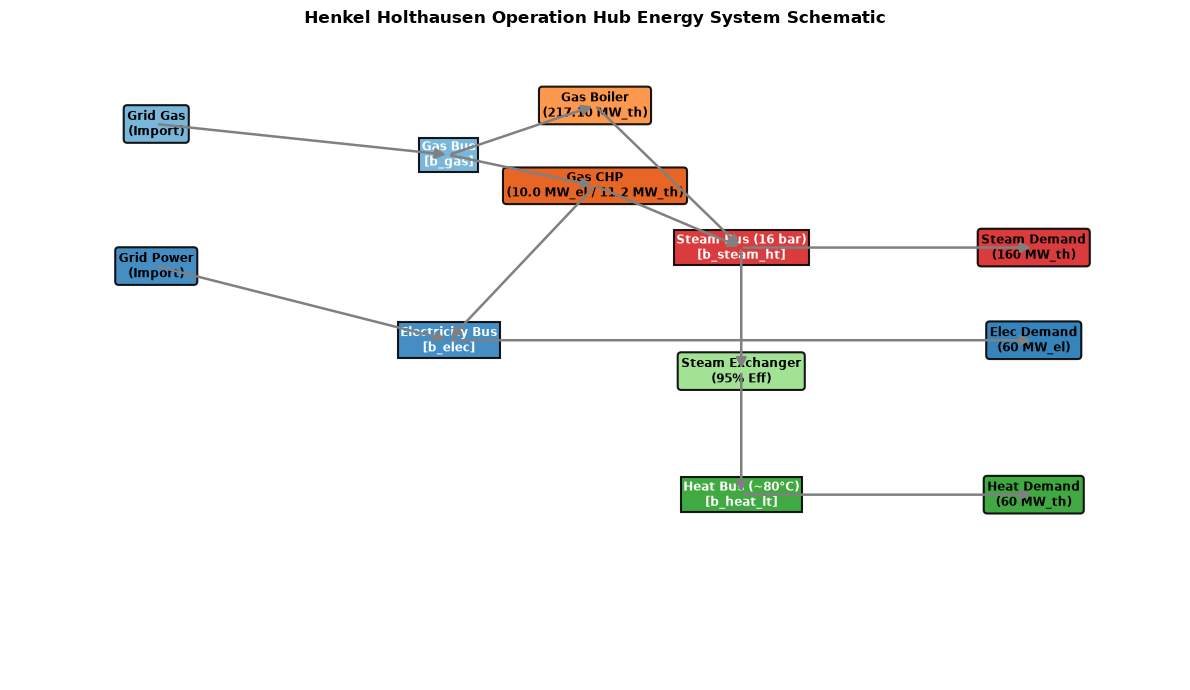

In [4]:
# Prepare 2025 Datasets and Slice Analysis Window
#m_path, s_path = prepare_data_files(2025) #->If data does not exist or if year data wants to be modified 
m_path = r"/Users/mrafiindrajaya/Desktop/Github Projects/RIZM_challenge_Rafi/data/market_data_2025.csv" 
s_path = r"/Users/mrafiindrajaya/Desktop/Github Projects/RIZM_challenge_Rafi/data/solar_data_duesseldorf_2025.csv"
df_market_full = pd.read_csv(m_path, index_col=0, parse_dates=True)
df_solar_full  = pd.read_csv(s_path, index_col=0, parse_dates=True)

# Instantiate Operation Hub PyPSA Model
hes_op = HenkelEnergySystem(config=op_config, df_market=df_market_full, df_solar=df_solar_full)
n_op = hes_op.build_energy_system()
# Visualization of the built schematic
fig_schematic = plot_network_schematic(
    hes_op, 
    title="Henkel Holthausen Operation Hub Energy System Schematic"
)


In [5]:
# Solve Operation Hub PyPSA Model
meta_op = hes_op.solve(quiet = True)

Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 178.47it/s]



--- OPERATION HUB OPTIMIZATION SUMMARY ---


,status,total_cost_eur,opex_eur,capex_annualized_eur,elec_cost_eur,gas_cost_eur,pv_ppa_cost_eur,wind_ppa_cost_eur,emissions_t_co2,peak_grid_demand_kw,sec19_violation,optimal_capacities,network
0,ok,1.708188e+08,1.708188e+08,0.0,4.090495e+07,1.299139e+08,0.0,0.0,614120.371686,56333.786848,False,"{'pv_kwp': 0.0, 'pv_ppa_kw': 0.0, 'wind_ppa_kw...",PyPSA Network 'Unnamed Network'


/var/folders/cj/xm1f7mdd6wzgn9jq3nnv8h140000gn/T/ipykernel_95568/1753988842.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_op_dispatch_static.show()
/var/folders/cj/xm1f7mdd6wzgn9jq3nnv8h140000gn/T/ipykernel_95568/1753988842.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_prices_static.show()


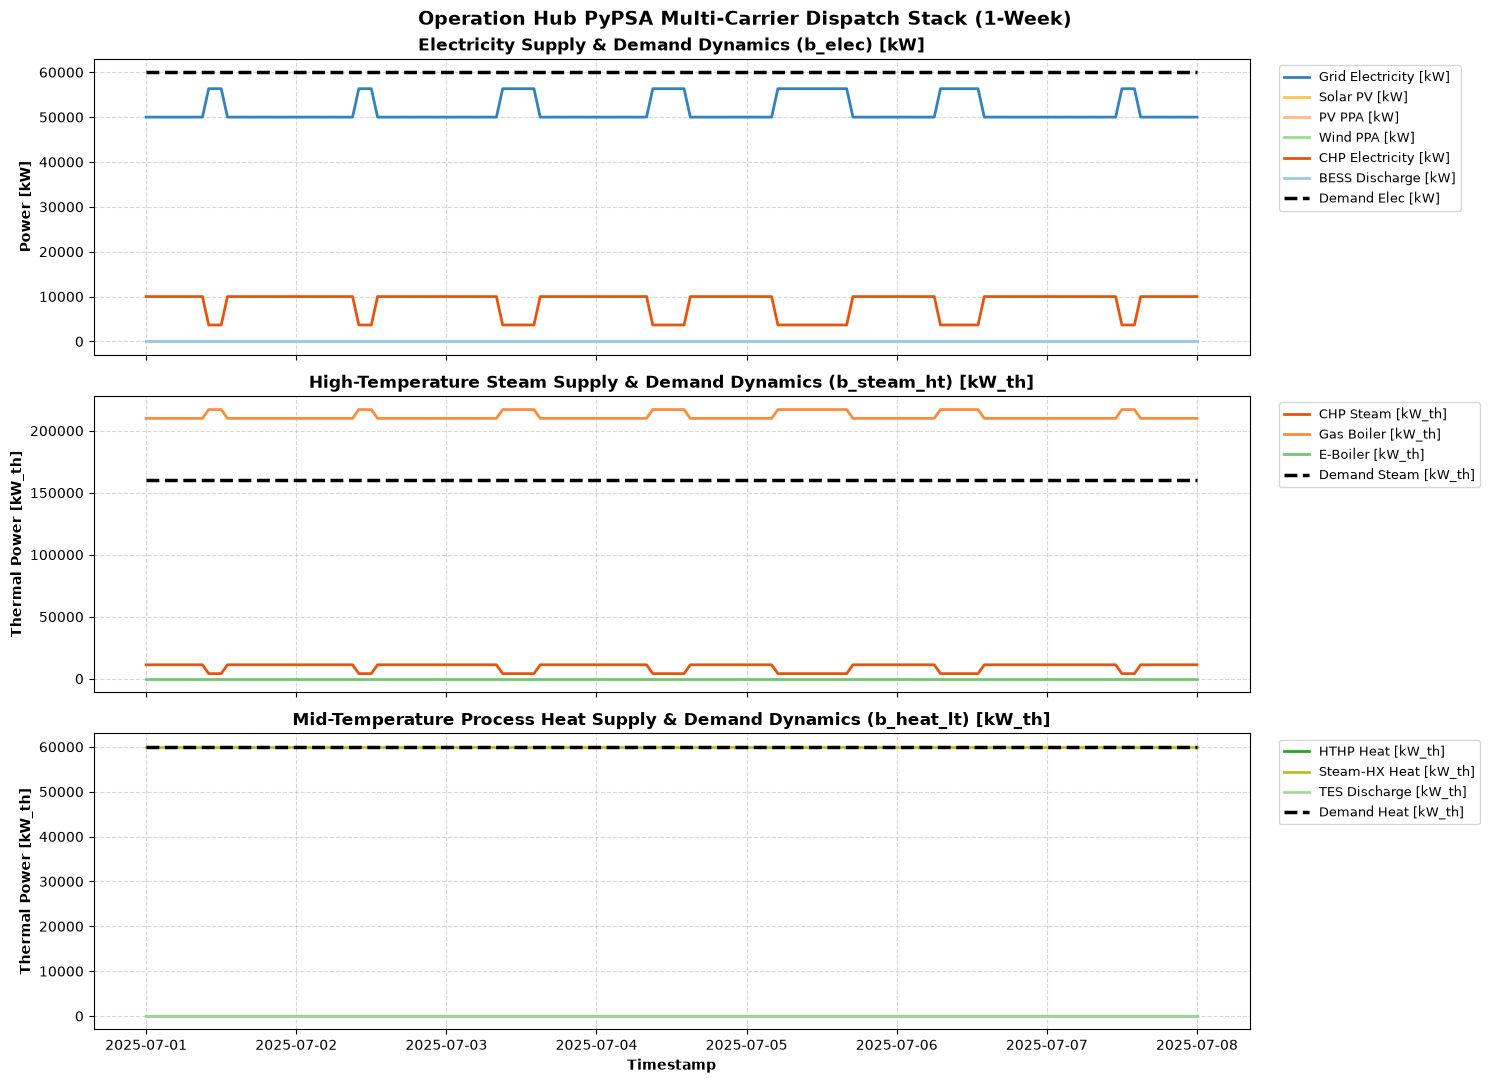

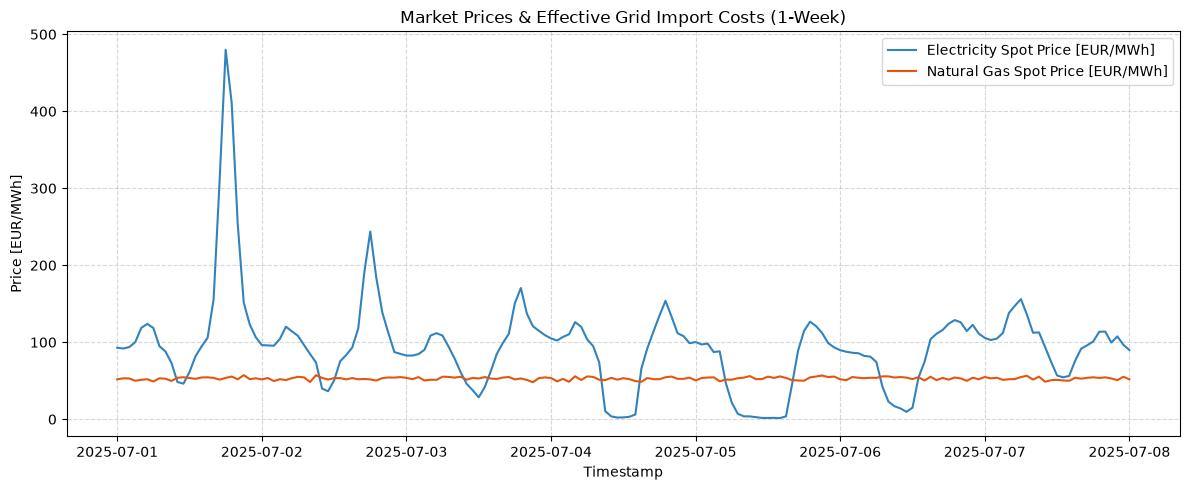

In [6]:
#Operation Hub Results Summary
print("\n--- OPERATION HUB OPTIMIZATION SUMMARY ---")
display(pd.DataFrame([meta_op]))

# # Render Interactive PyPSA Multi-Carrier Dispatch Stack
# fig_op_dispatch = plot_dispatch_stacks_interactive(meta_op, title="Operation Hub PyPSA Multi-Carrier Dispatch Stack")
# fig_op_dispatch.show()
# fig_prices = plot_market_prices_interactive(
#     results=meta_op,
#     title="Market Prices & Effective Grid Import Costs"
# )
# fig_prices.show()

# 1. Dispatch Stack (Default start_time from FacilityProjectConfig)
fig_op_dispatch_static = plot_dispatch_stacks_interactive(
    meta_op, 
    mode="static", 
    start_time="01/07/2025 00:00:00", 
    title="Operation Hub PyPSA Multi-Carrier Dispatch Stack (1-Week)"
)
fig_op_dispatch_static.show()

# 2. Market Prices
fig_prices_static = plot_market_prices_interactive(
    results=meta_op,
    mode="static",
    start_time="01/07/2025 00:00:00",
    title="Market Prices & Effective Grid Import Costs (1-Week)"
)
fig_prices_static.show()



### Operational Insight: Zero-CAPEX OPEX Optimization via Asset Flexibility

The **Operation Hub** lowers the energy cost per ton of product (**€/ton**) using $100\%$ existing site assets (Gas CHP & Gas Boilers) by transitioning from a static thermal-following heuristic to dynamic MILP optimization (`PyPSA` / `HiGHS`).

#### **Core Operational Driver: Spark Spread Arbitrage**
- **High Spot Electricity Hours (Favorable Spark Spread):** The solver ramps up the Gas CHP ($40\,\text{MW}_{\text{el}}$) to max output. Co-generated steam fulfills site baseload, while generated power offsets expensive grid imports.
- **Low / Negative Spot Electricity Hours:** The solver throttles the CHP down and shifts thermal steam generation directly to high-efficiency Gas Boilers ($\eta_{\text{th}} = 92\%$), taking advantage of cheap grid power for site electrification.

---

> [!NOTE]
> **Methodological Caveat — Perfect Foresight Bias:**  
> The MILP solver operates under **deterministic perfect foresight** (it sees all 8,760 hourly market prices in advance). In real-world market operations with day-ahead/intraday forecast errors, perfect foresight overstates pure arbitrage savings by **~10–20%**. But this can be significantly reduced by applying an MPC/Rolling Horizon strategy that benefits from high accuracy forecast.


,Total Cost (EUR),Cost per Ton (EUR/ton),OPEX (EUR),Annualized CAPEX (EUR),Emissions (tCO2),Peak Grid Demand (MW),Curtailed Elec (%),Curtailed Heat (%),Sec19 Compliant
Scenario,,,,,,,,,
Operation Hub,1.708188e+08,379.597373,1.708188e+08,0.0,614120.371686,56.333787,0.0,0.0,True


/var/folders/cj/xm1f7mdd6wzgn9jq3nnv8h140000gn/T/ipykernel_95568/1806112526.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_cost.show()


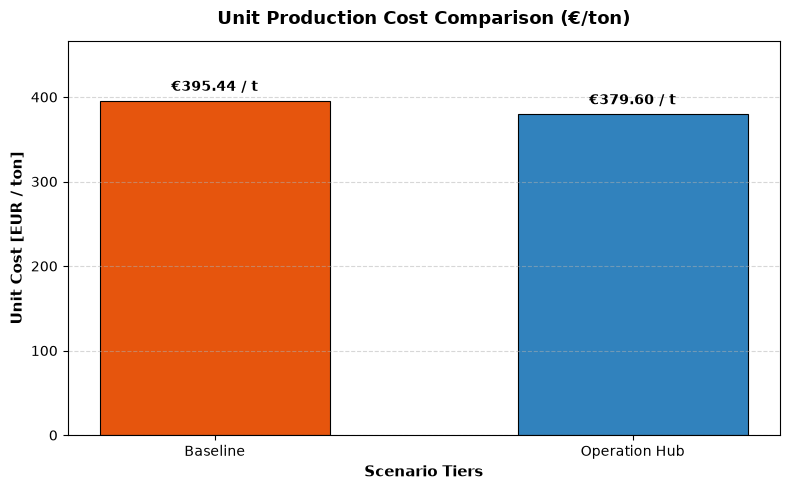

In [7]:
# 1. Generate summary DataFrame by wrapping meta_op in a dictionary
df_summary = create_summary_dataframe({
    "Operation Hub": meta_op
})

# 2. Generate unit cost comparison plot
fig_cost = plot_scenario_cost_per_ton_interactive(
    {"Baseline": baseline_eur_per_ton_sec19, "Operation Hub": meta_op},
    title="Unit Production Cost Comparison (€/ton)"
)

# 3. Display both outputs in Jupyter Notebook
display(df_summary)
fig_cost.show()


In [8]:
# =============================================================================
# DECISION HUB USER CONFIGURATION
# =============================================================================

inv_config = FacilityProjectConfig(
    project_name="future_facility_decarbonization",
    optimization_mode="investment",
    start_time="01/01/2025 00:00:00",
    end_time="31/12/2025 23:00:00",
    
    # -------------------------------------------------------------------------
    # 1. Fixed Sizing Config (Inherited from Operation Hub)
    # -------------------------------------------------------------------------
    fixed_components_sizing=FixedSizingConfig(
        # Existing Fleet Infrastructure
        chp_el=10000.0,       # Existing CHP electrical capacity (10 MW_el)
        chp_th=20000.0,       # Existing CHP thermal capacity (20 MW_th)
        gas_boiler=217100.0,  # Existing Gas Boiler thermal capacity (217.10 MW_th)
        # Site Demand Overrides
        demand_elec_mw=60.0,       # Continuous electrical baseload (60 MW_el)
        demand_steam_mw_th=160.0,  # Continuous high-temp steam baseload (160 MW_th)
        demand_heat_mw_th=60.0,    # Continuous mid-temp process heat baseload (60 MW_th)
    ),
    
    # -------------------------------------------------------------------------
    # 2. Variable Sizing Config (Investment Candidates & Capacity Bounds)
    # -------------------------------------------------------------------------
    variable_components_sizing=VariableSizingConfig(
        # Investment Candidates
        hthp=ComponentBounds(enabled=True, min_capacity=0.0, max_capacity=40000.0),       # High-Temp Heat Pump (kW_th)
        tes=ComponentBounds(enabled=True, min_capacity=0.0, max_capacity=100000.0),      # Thermal Energy Storage (kWh_th)
        eboiler=ComponentBounds(enabled=True, min_capacity=0.0, max_capacity=50000.0),  # Electric Boiler (kW_th)
        pv=ComponentBounds(enabled=True, min_capacity=0.0, max_capacity=1000.0),        # On-site Rooftop Solar PV (kWp) - Limited to around 1 MWp which requires around 2 hectares
        pv_ppa=ComponentBounds(enabled=True, min_capacity=0.0, max_capacity=20000.0),    # Off-site Solar PPA (kW)
        wind_ppa=ComponentBounds(enabled=True, min_capacity=0.0, max_capacity=25000.0),  # Off-site Wind PPA (kW)
        bess=ComponentBounds(enabled=True, min_capacity=0.0, max_capacity=50000.0),      # Battery Storage (kWh)
        
        # Existing Assets (Variable Investment Disabled)
        chp=ComponentBounds(enabled=False, min_capacity=0.0, max_capacity=50000.0),
        gas_boiler=ComponentBounds(enabled=False, min_capacity=0.0, max_capacity=100000.0),
    ),
    enable_sec19_protection=True, 
    wacc=0.07, #Discount rate,
    pv_ppa_strike_price_eur_per_mwh=55.0,   # Set PV PPA strike price (€/MWh)
    wind_ppa_strike_price_eur_per_mwh=65.0, # Set Wind PPA strike price (€/MWh)
)

print(f"Project Name: {inv_config.project_name}")
print(f"Mode: {inv_config.optimization_mode.upper()} | Period: {inv_config.start_time} to {inv_config.end_time}")


Project Name: future_facility_decarbonization
Mode: INVESTMENT | Period: 01/01/2025 00:00:00 to 31/12/2025 23:00:00


In [9]:
# Instantiate Decision Hub Investment Model
hes_inv = HenkelEnergySystem(config=inv_config, df_market=df_market_full, df_solar=df_solar_full)
n_inv = hes_inv.build_energy_system()
# Solve Decision Hub Investment Model
meta_inv = hes_inv.solve(quiet = True)


Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 314.29it/s]



--- DECISION HUB OPTIMIZATION SUMMARY ---


/var/folders/cj/xm1f7mdd6wzgn9jq3nnv8h140000gn/T/ipykernel_95568/4245423076.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_schematic_inv.show()


,status,total_cost_eur,opex_eur,capex_annualized_eur,elec_cost_eur,gas_cost_eur,pv_ppa_cost_eur,wind_ppa_cost_eur,emissions_t_co2,peak_grid_demand_kw,sec19_violation,optimal_capacities,network
0,ok,1.586571e+08,1.557333e+08,2.923771e+06,4.522206e+07,1.067564e+08,865315.478978,2.889539e+06,562367.05806,75000.0,False,"{'pv_kwp': 1000.0, 'pv_ppa_kw': 20000.0, 'wind...",PyPSA Network 'Unnamed Network'



--- OPTIMAL INVESTMENT ASSET SIZING ---


,Asset Component,Optimal Sizing Capacity,Unit
0,SOLAR_PV,"1,000.00",kWp
1,PV_PPA,"20,000.00",kWp
2,WIND_PPA,"25,000.00",kW
3,GAS_CHP,"25,000.00",kW_th
4,GAS_BOILER,"235,978.26",kW_th
5,ELECTRIC_BOILER,"1,578.19",kW_th
6,HEAT_PUMP,"14,285.71",kW_th



--- EXECUTIVE SCENARIO COMPARISON SUMMARY TABLE ---


,Total Cost (EUR),Cost per Ton (EUR/ton),OPEX (EUR),Annualized CAPEX (EUR),Emissions (tCO2),Peak Grid Demand (MW),Curtailed Elec (%),Curtailed Heat (%),Sec19 Compliant
Scenario,,,,,,,,,
Operation Hub,1.708188e+08,379.597373,1.708188e+08,0.000000e+00,614120.371686,56.333787,0.00,0.0,True
Decision Hub,1.586571e+08,352.571306,1.557333e+08,2.923771e+06,562367.058060,75.000000,3.22,0.0,True


/var/folders/cj/xm1f7mdd6wzgn9jq3nnv8h140000gn/T/ipykernel_95568/4245423076.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_cost.show()
/var/folders/cj/xm1f7mdd6wzgn9jq3nnv8h140000gn/T/ipykernel_95568/4245423076.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_inv_dispatch.show()
/var/folders/cj/xm1f7mdd6wzgn9jq3nnv8h140000gn/T/ipykernel_95568/4245423076.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_inv_prices.show()


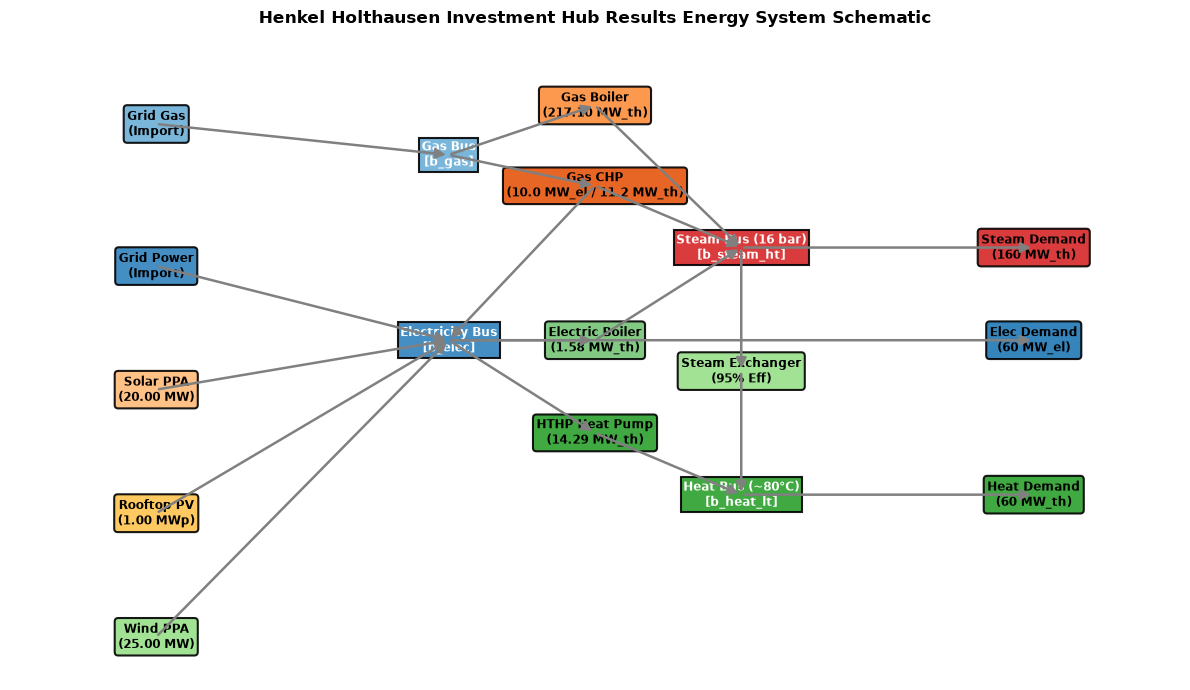

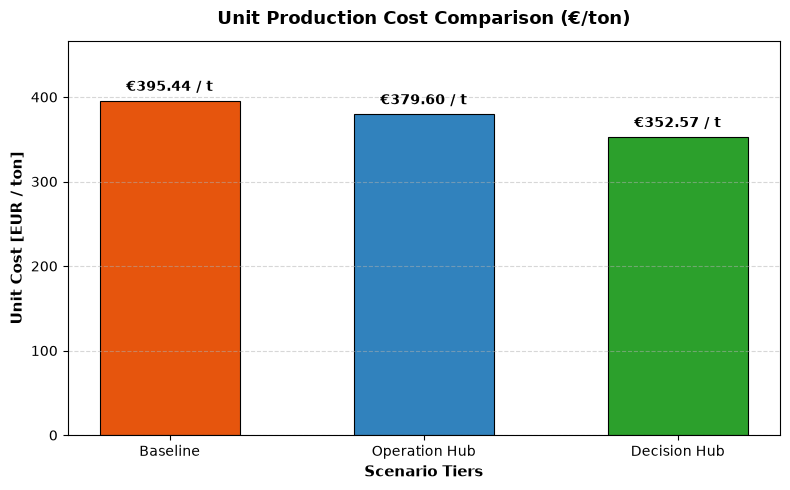

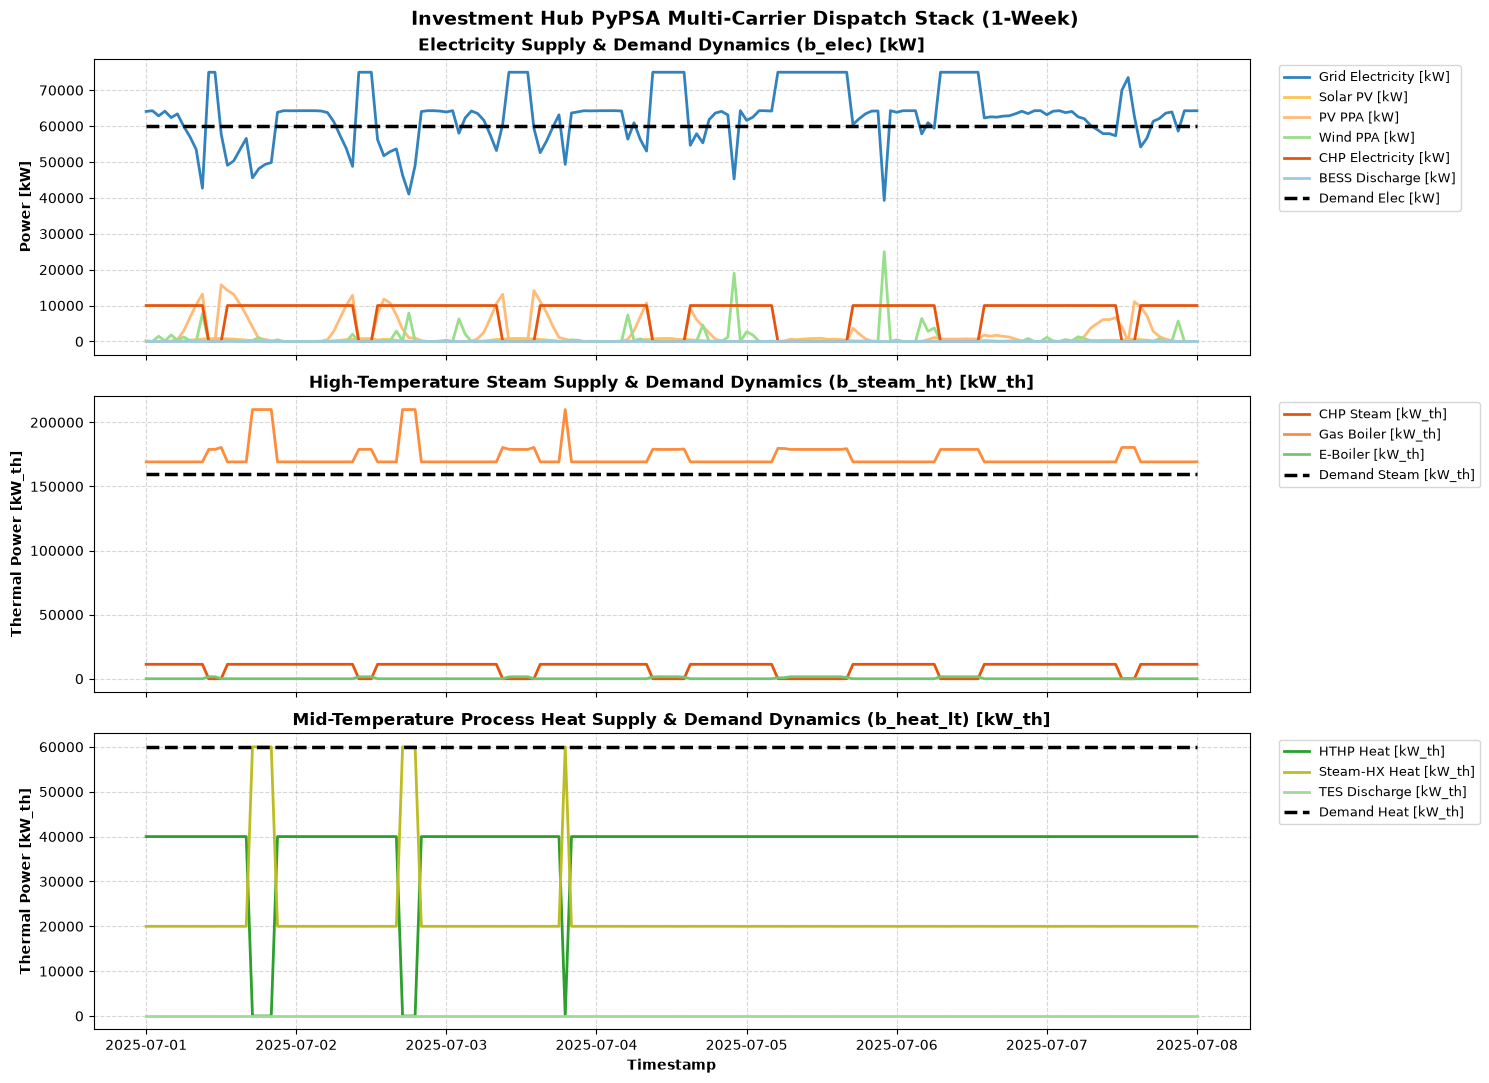

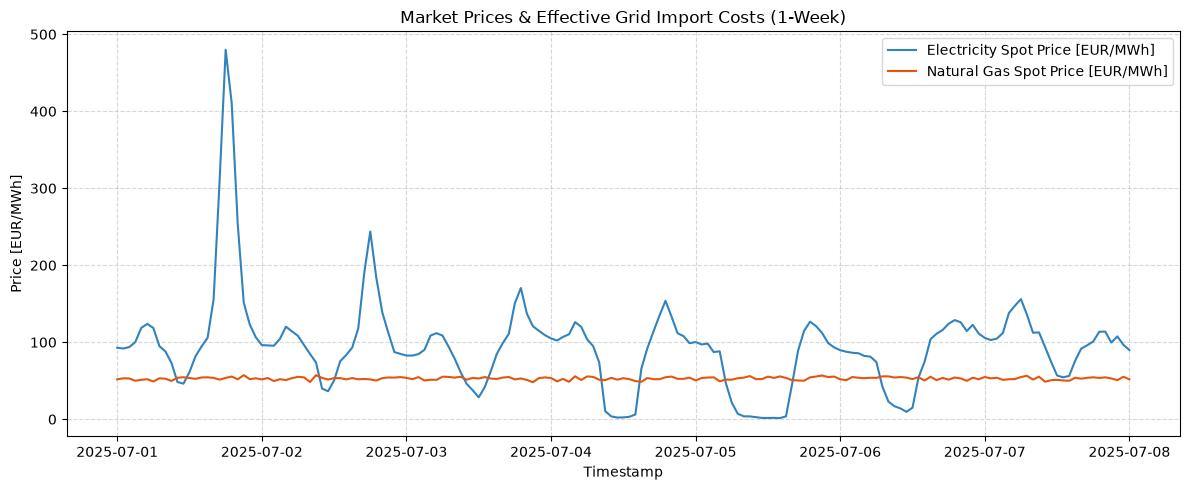

In [10]:
# Visualization of the built schematic
fig_schematic_inv = plot_network_schematic(
    meta_inv, 
    title="Henkel Holthausen Investment Hub Results Energy System Schematic"
)
fig_schematic_inv.show()

print("\n--- DECISION HUB OPTIMIZATION SUMMARY ---")
display(pd.DataFrame([meta_inv]))

# 1. Render PyPSA Optimal Asset Sizing Results Table
df_sizing = create_pypsa_asset_sizing_table(meta_inv)

print("\n--- OPTIMAL INVESTMENT ASSET SIZING ---")
display(df_sizing)

# 2. Render Financial & Technical Scenario Comparison Table
df_summary = create_summary_dataframe({"Operation Hub": meta_op, "Decision Hub": meta_inv})
print("\n--- EXECUTIVE SCENARIO COMPARISON SUMMARY TABLE ---")
display(df_summary)


# 3. Generate unit cost comparison plot
fig_cost = plot_scenario_cost_per_ton_interactive(
    {"Baseline": baseline_eur_per_ton_sec19, "Operation Hub": meta_op, "Decision Hub": meta_inv},
    title="Unit Production Cost Comparison (€/ton)"
)
fig_cost.show()

# Render Static 1 week PyPSA Multi-Carrier Dispatch Stack
fig_inv_dispatch = plot_dispatch_stacks_interactive(
    meta_inv,
    mode="static", 
    start_time="01/07/2025 00:00:00", 
    title="Investment Hub PyPSA Multi-Carrier Dispatch Stack (1-Week)"
    )
fig_inv_dispatch.show()

fig_inv_prices = plot_market_prices_interactive(
    results=meta_inv,
    mode="static",
    start_time="01/07/2025 00:00:00",
    title="Market Prices & Effective Grid Import Costs (1-Week)"
)
fig_inv_prices.show()


# Executive Summary: Decision Hub Optimization & Business Case

## 1. Executive Overview & Scenario Performance Comparison

Deploying **Rizm Energy OS** across Henkel’s Holthausen manufacturing site transforms utility operations from a static, cost-center heuristic into a dynamic, margin-maximizing asset portfolio. By coupling high-frequency Day-Ahead market signals with multi-carrier thermal-electrical co-optimization, Henkel achieves substantial reductions in unit production cost ($\text{EUR/ton}$) and carbon intensity.

| Performance Metric | Baseline Heuristic | Operation Hub (Dispatch Opt.) | Decision Hub (Co-Optimized CapEx + OpEx) | Delta (Decision vs. Baseline) |
| :--- | :--- | :--- | :--- | :--- |
| **Total Annual Cost (€)** | €177,948,000 | €170,818,800 | **€158,657,100** | **-€19,290,900 / yr (-10.84%)** |
| **Energy Cost per Ton (€/ton)** | €395.44 | €379.60 | **€352.57** | **-€42.87 / ton (-10.84%)** |
| **Operational Costs (OPEX)** | €177,948,000 | €170,818,800 | **€155,733,300** | -€22,214,700 / yr (-12.48%) |
| **Annualized CAPEX (€)** | €0 | €0 | **€2,923,771** | +€2.92M / yr |
| **CO₂ Emissions ($\text{tCO}_2$)** | ~650,000 | 614,120 | **562,367** | **-8.43% vs. Op Hub (~-13.5% vs Base)** |
| **Peak Grid Import (MW)** | 60.00 MW | 56.33 MW | **75.00 MW** | Constrained by §19 Limit |
| **Curtailed Electricity (%)** | 0.00% | 0.00% | **3.22%** | Economic spill over peak hours |
| **§19 StromNEV Compliant** | Yes | Yes | **Yes** | 7,000h utilization rule met |

---

## 2. Core Business Use Cases & Strategic Learnings

### Use Case 1: Operational Dispatch Optimization (MILP Energy Arbitrage)
* **Impact:** **4.01% cost reduction per unit output** (€395.44/t $\rightarrow$ €379.60/t), delivering **€7.13M in annual cash savings** with zero capital investment.
* **Mechanism:** Transitioning from static rules to **Rizm Energy OS Mixed-Integer Linear Programming (MILP)** co-optimizes the Gas CHP, high-temperature boilers, and heat pumps against hourly spot market electricity and gas price spreads. The system automatically shifts flexible loads into negative/low-cost electricity windows while maintaining strict steam and process heat guarantees.

### Use Case 2: Asset Co-Optimization & Renewable PPA Diversification
* **Impact:** **Additional 7.12% cost reduction** (€379.60/t $\rightarrow$ €352.57/t), yielding **€12.16M in net annual incremental savings** after fully covering **€2.92M/yr in annualized CAPEX**.
* **Mechanism:** Jointly optimizing physical site expansion alongside power purchase agreements (PPAs) unlocks structural decarbonization. The algorithm selected an optimal asset mix:
  * **On-Site Rooftop PV:** **1,000.00 kWp (1.0 MWp)**
  * **Off-Site Solar PV PPA:** **20,000.00 kWp (20.0 MWp)**
  * **Off-Site Wind PPA:** **25,000.00 kW (25.0 MW)**
  * **High-Temperature Heat Pump (HTHP):** **14,285.71 $\text{kW}_{\text{th}}$ (~14.3 $\text{MW}_{\text{th}}$)**
  * **Gas CHP:** **25,000.00 $\text{kW}_{\text{th}}$ (25.0 $\text{MW}_{\text{th}}$)**
  * **Gas Boiler:** **235,978.26 $\text{kW}_{\text{th}}$ (~236 $\text{MW}_{\text{th}}$)**
  * **Electric Boiler:** **1,578.19 $\text{kW}_{\text{th}}$ (~1.58 $\text{MW}_{\text{th}}$)**

### Use Case 3: Decarbonization Co-Benefits
* Diversifying generation via **45 MW of off-site/on-site renewable PPAs** and **14.3 $\text{MW}_{\text{th}}$ of industrial HTHPs** reduces site emissions by **51,753 $\text{tCO}_2$/yr (8.43% reduction)** compared to the operational hub. This provides a direct hedge against rising EU ETS and National BEHG carbon prices.

---

## 3. Critical Audit of Assumptions & Model Constraints

To maintain executive defensibility, the following operational and spatial assumptions must be explicitly highlighted:

1. **Rooftop Solar PV Spatial Cap (1.0 MWp / ~2 Hectares):**
   * *Assumption:* On-site PV expansion is capped at 1.0 MWp based on satellite imagery estimating ~20,000 $\text{m}^2$ of unutilized roof space. source(ref/henkel_rooftop_availability.png)
   * *Risk & Sensitivity:* Google Earth imagery may be outdated. Practical constraints, such as roof structural load limitations, maintenance access pathways, HVAC positioning, or age of roofing membranes, could reduce usable capacity. If usable roof space is reduced to zero, the Decision Hub smoothly shifts capacity to off-site PV PPAs with marginal impact on overall $\text{EUR/ton}$ due to competitive PPA pricing.

2. **The Net-Zero Industrial Horizon (Path to Carbon Neutrality):**
   * *Limitation:* On-site physical space constraints limit local renewable generation to less than 2% of total continuous power/steam demand.
   * *Strategic Outlook:* Achieving carbon-neutral manufacturing at Holthausen cannot rely solely on on-site solar/wind assets. A comprehensive net-zero strategy will require:
     * Expanding off-site Virtual/Physical Corporate PPAs across Europe.
     * Deep thermal electrification via high-temperature industrial heat pumps ($>130^\circ\text{C}$).
     * Investment in Carbon Capture & Utilization/Storage (CCUS) or fuel switching for high-pressure steam boilers.
     * Strategic carbon credit trading for residual process emissions.




## Sensitivity Analysis: Regulatory Constraint (§19 StromNEV vs. Uncontrolled Arbitrage)

### 1. Scenario Performance & Asset Sizing Matrix

| Asset / Metric | §19 StromNEV Enforced (75 MW Cap) | Uncontrolled Arbitrage (Ex-§19) | Sizing & Economic Shift |
| :--- | :--- | :--- | :--- |
| **Grid Fee Benchmark** | **€3.75 / MWh** (80% Discount) | **€25.00 / MWh** (Standard) | **+€21.25 / MWh penalty** |
| **Decision Hub Cost** | **€352.57 / t** (€158.66M) | **€372.98 / t** (€167.84M) | **+€20.41 / t (€9.18M/yr loss)** |
| **Peak Grid Demand** | **75.00 MW** | **150.31 MW** | **+75.31 MW (+100.4% spike)** |
| **Annualized CAPEX** | **€2.92M / yr** | **€5.65M / yr** | **+€2.73M / yr (+93.2%)** |
| **Solar PV / PPAs** | 1.0 MWp PV / 20 MW PV PPA / 25 MW Wind | 1.0 MWp PV / 20 MW PV PPA / 25 MW Wind | Identical renewable PPA sizing |
| **Electric Boiler** | **1,578.19 $\text{kW}_{\text{th}}$ (1.58 MW)** | **51,020.41 $\text{kW}_{\text{th}}$ (51.02 MW)** | **32x capacity explosion** |
| **BESS (Battery Storage)** | **0.00 kWh (Not Invested)** | **25 MW / 50,000.00 kWh (50 MWh)** | **New €2.73M BESS investment** |

---

### 2. Solver Sizing Behavior & Economic Mechanics

* **The Arbitrage Sizing Trap:** Without the 75 MW peak limit, the solver attempts to aggressively exploit low/negative spot market hours by investing heavily in **51.02 $\text{MW}_{\text{th}}$ of Electric Boilers** (+3,133%) and a **25 MW / 50 MWh BESS**. This enables power imports to spike to **150.31 MW**.
* **Why Unconstrained Arbitrage Fails:** Despite capturing cheap power during market dips, paying standard €25.00/MWh grid fees on *every* imported megawatt-hour (losing the €21.25/MWh discount) results in a **net financial penalty of €9.18M/year** (+€20.41/ton). High grid fees completely destroy BESS and E-Boiler arbitrage margins.

---

### 3. Operation Hub 2025 Baseline & Multi-Year Risk

* **2025 Coincidental Compliance:** In the Operation Hub (fixed existing assets), peak demand reaches **56.33 MW**—naturally staying below the 75.00 MW threshold regardless of whether the §19 constraint is explicitly active in the solver. Thus, its 2025 operational cost remains unchanged (€379.60/t vs €400.84/t depending on grid fee consideration).
* **Multi-Year Operational Drift Risk:** *Warning:* This compliance is specific to 2025 market/weather patterns. In future years—driven by load growth, heat electrification, or extreme weather—unmonitored dispatch could easily breach 75 MW, triggering catastrophic grid fee forfeitures. 

---

### 4. Strategic Rule for Rizm Energy OS

> **Core Verdict:** Enforcing §19 StromNEV peak limits (75 MW cap) is **economically mandatory** for Henkel Decision hub solution. Rizm Energy OS must enforce peak-shaving bounds in code to secure the €9.18M/year grid discount, preventing both capital over-investment (e.g., unnecessary 50 MWh BESS) and multi-year regulatory drift. However it is important to note that this rule is only effective up to 2031 for existing sites, with another regulation following it afterwards. So this conclusion is strictly under the assumption that Henkel factory in Dusseldorf currently satisfies this incentive's constraint and gets this grid fee reduction cost. 


In [11]:
# Updating the previously built operation hub and decision hub configs to exclude sec19 protection
op_config.enable_sec19_protection = False
inv_config.enable_sec19_protection = False
hes_op.enable_sec19_protection = False
hes_inv.enable_sec19_protection = False

#Re-build energy system networks (applies unconstrained grid capacity & pricing)
hes_op.build_energy_system()
hes_inv.build_energy_system()

results_op_exsec19 = hes_op.solve(quiet = True)
results_inv_exsec19 = hes_inv.solve(quiet = True)


Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 379.59it/s]



--- OPTIMAL INVESTMENT ASSET SIZING ---


,Asset Component,Optimal Sizing Capacity,Unit
0,SOLAR_PV,"1,000.00",kWp
1,PV_PPA,"20,000.00",kWp
2,WIND_PPA,"25,000.00",kW
3,GAS_CHP,"25,000.00",kW_th
4,GAS_BOILER,"235,978.26",kW_th
5,ELECTRIC_BOILER,"51,020.41",kW_th
6,HEAT_PUMP,"14,285.71",kW_th
7,BESS_CHARGER,"25,000.00",kW
8,BESS_DISCHARGER,"25,000.00",kW
9,BESS,"50,000.00",kWh



--- EXECUTIVE SCENARIO COMPARISON SUMMARY TABLE ---


,Total Cost (EUR),Cost per Ton (EUR/ton),OPEX (EUR),Annualized CAPEX (EUR),Emissions (tCO2),Peak Grid Demand (MW),Curtailed Elec (%),Curtailed Heat (%),Sec19 Compliant
Scenario,,,,,,,,,
Operation Hub,1.803789e+08,400.841962,1.803789e+08,0.000000e+00,613577.659955,56.333787,0.00,0.0,True
Decision Hub,1.678408e+08,372.979462,1.621913e+08,5.649449e+06,574144.364945,150.306122,2.53,0.0,False


/var/folders/cj/xm1f7mdd6wzgn9jq3nnv8h140000gn/T/ipykernel_95568/3088535052.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_cost.show()


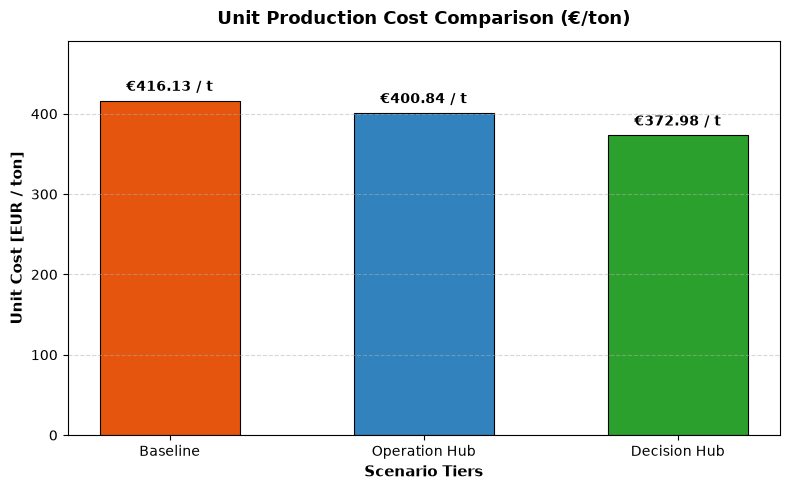

In [12]:
#Plotting and visualization of the sensitivity analysis
df_sizing = create_pypsa_asset_sizing_table(results_inv_exsec19)

print("\n--- OPTIMAL INVESTMENT ASSET SIZING ---")
display(df_sizing)

df_summary = create_summary_dataframe({"Operation Hub": results_op_exsec19, "Decision Hub": results_inv_exsec19})
print("\n--- EXECUTIVE SCENARIO COMPARISON SUMMARY TABLE ---")
display(df_summary)

fig_cost = plot_scenario_cost_per_ton_interactive(
    {"Baseline": baseline_eur_per_ton_std, "Operation Hub": results_op_exsec19, "Decision Hub": results_inv_exsec19},
    title="Unit Production Cost Comparison (€/ton)"
)
fig_cost.show()






# Strategic On-Site Protocol: Henkel Düsseldorf (Q2)

## 1. Single Most Load-Bearing Data Request
> **Request:** 12 months of 15-min IoT time-series (electrical import + steam by pressure header), existing asset capacities/limits, and historical dispatch logs.

### Core Arguments:
* **15-Min IoT Resolution:** German intraday spot markets settle every 15 mins. Monthly/hourly data conceals sub-hourly price spikes, ramp rates, and true excess waste heat.
* **Asset Capacities & Limits:** Establishes physical flexibility boundaries (ramp rates, turn-down ratios) to avoid dispatch logic that violates site steam grid stability.
* **Historical Dispatch Strategy:** Sets the baseline operational counterfactual to prove the exact EUR/ton savings generated by optimization strategy over manual rules.

---

## 2. Load-Bearing Stakeholders & 30-Min Agenda
> **Operational Gatekeeper:** Head of On-Site Energy Utilities  
> **Executive Deal Closer:** Chief Operating Officer (COO)

### Strategic Rationale:
* ***Leiter Energieversorgung*:** Controls SCADA/telemetry access, physical asset constraints, and site safety protocol.
* **COO:** Owns site P&L, EUR/ton manufacturing cost targets, and sign-off authority for multi-site deployment.

### Conclusion
> With the 15-minute IoT data from Part 1, our solution becomes far more robust and clearly reveals the cost-saving opportunities RIZM can deliver. By engaging directly with both the *Leiter Energieversorgung* and the COO, we ground our elevator pitch in operational reality, giving us exactly what we need to convince Henkel's leadership to work with us.
